In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


Found 368 image files.
Training classification head...
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.8208 - loss: 0.3775 - val_accuracy: 1.0000 - val_loss: 0.0166
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - a

2025-03-17 22:27:24.581871: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


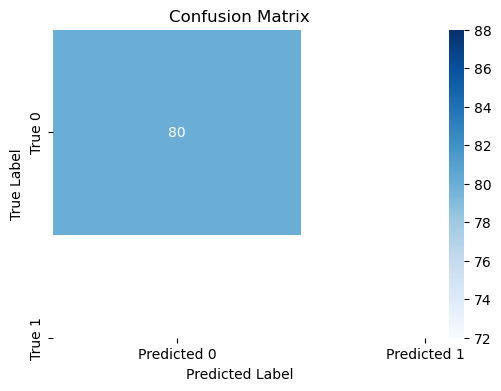

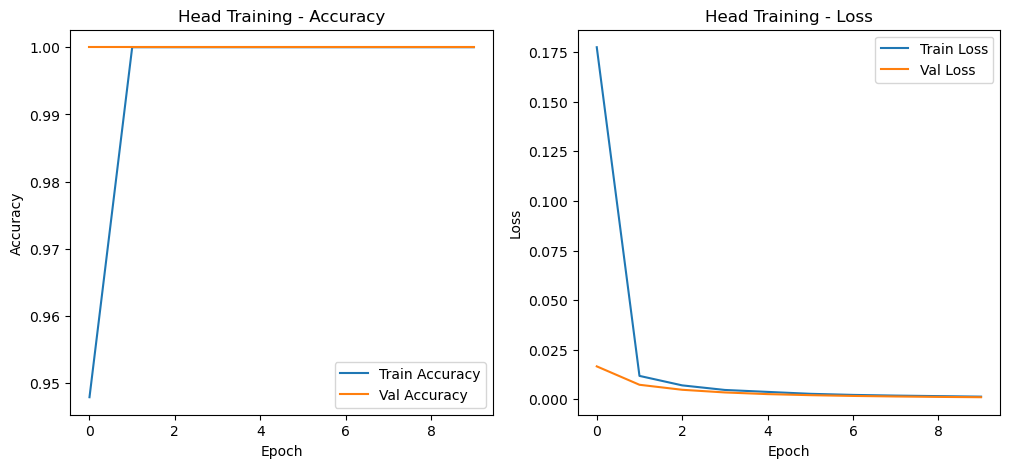

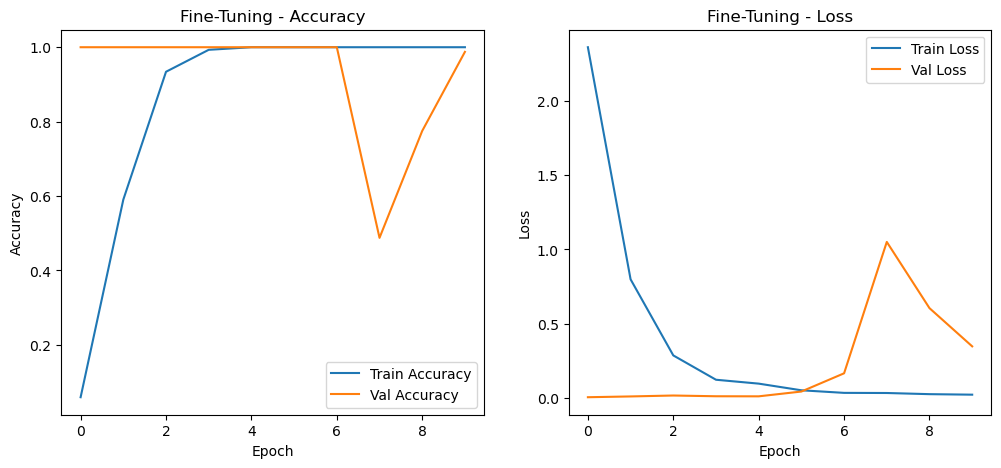

In [ ]:
import os
import glob
import nibabel as nib
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_HEIGHT, IMG_WIDTH = 300, 300
BATCH_SIZE = 8
EPOCHS_HEAD = 10
EPOCHS_FINE = 10

def load_and_preprocess_image(filepath):
    filepath_str = filepath.numpy().decode('utf-8')
    ext = os.path.splitext(filepath_str)[1].lower()

    if ext in ['.nii', '.nii.gz']:
        nii_img = nib.load(filepath_str)
        data = nii_img.get_fdata()
        binary_mask = (data > 0).astype(np.float32)
        central_slice = binary_mask[:, :, binary_mask.shape[2] // 2]
        processed = cv2.resize(central_slice, (IMG_WIDTH, IMG_HEIGHT))
        img_3ch = np.stack([processed] * 3, axis=-1)
    else:
        img_cv = cv2.imread(filepath_str, cv2.IMREAD_COLOR)
        if img_cv is None:
            raise ValueError(f"Could not read image file: {filepath_str}")
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        img_3ch = cv2.resize(img_cv, (IMG_WIDTH, IMG_HEIGHT)).astype(np.float32) / 255.0

    return img_3ch

def tf_load_image(filepath):
    img = tf.py_function(func=load_and_preprocess_image, inp=[filepath], Tout=tf.float32)
    img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
    return img

root_dir = '/media/fast/New Volume/FAST/Asim/archive(1)/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
file_paths = glob.glob(os.path.join(root_dir, 'BraTS20_Training_*', '*_seg.nii'))
file_paths += glob.glob(os.path.join(root_dir, 'BraTS20_Training_*', '*.png'))
file_paths += glob.glob(os.path.join(root_dir, 'BraTS20_Training_*', '*.jpg'))
print(f"Found {len(file_paths)} image files.")

def get_label(filepath):
    ext = os.path.splitext(filepath)[1].lower()
    return 1 if ext in ['.nii', '.nii.gz'] else 0

labels = [get_label(fp) for fp in file_paths]

dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

def _process(filepath, label):
    img = tf_load_image(filepath)
    return img, label

dataset = dataset.map(_process, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=len(file_paths), reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

total_samples = len(file_paths)
train_size = int(0.8 * total_samples)
train_dataset = dataset.take(train_size // BATCH_SIZE)
val_dataset = dataset.skip(train_size // BATCH_SIZE)

base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Training classification head...")
history_head = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_HEAD
)

for layer in base_model.layers:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Fine-tuning the entire model...")
history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FINE
)

val_loss, val_accuracy = model.evaluate(val_dataset)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

y_true = []
y_pred = []
y_prob = []

for images, labels in val_dataset:
    probs = model.predict(images)
    preds = (probs >= 0.5).astype(int).flatten()
    y_pred.extend(preds)
    y_true.extend(labels.numpy())
    y_prob.extend(probs.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

unique_classes = np.unique(y_true)
print("Unique classes in validation set:", unique_classes)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

if len(unique_classes) == 2:
    roc_auc = roc_auc_score(y_true, y_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()
else:
    print("ROC-AUC Score is not defined since the validation set contains only one class:", unique_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["True 0", "True 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

plot_history(history_head, "Head Training")
plot_history(history_finetune, "Fine-Tuning")

In [ ]:
def run_inference(model, image_filepath):
    # Convert filepath string to tensor
    file_tensor = tf.convert_to_tensor(image_filepath)
    img = tf_load_image(file_tensor)  # Preprocess the image
    img = tf.expand_dims(img, axis=0)   # Add batch dimension
    prob = model.predict(img)[0][0]
    pred_class = 1 if prob >= 0.5 else 0
    return pred_class, prob

example_file = "/home/fast/Downloads/test.jpg"
predicted_class, probability = run_inference(model, example_file)
print(f"Inference result for '{example_file}': Predicted class = {predicted_class}, Probability = {probability:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Inference result for '/home/fast/Downloads/test.jpg': Predicted class = 1, Probability = 0.9832
